### Projet 1 - Contrôle de la propagation d'une maladie contagieuse

**À rendre avant le 19.12.2024 minuit.**

---

#### Synopsis

Dans ce projet, vous êtes confrontés à un problème de santé publique simulé : contrôler la propagation d'une maladie contagieuse dans une population humaine. Des experts en épidémiologie ont collecté des données en mesurant cinq caractéristiques distinctes (_x1_ à _x5_) pour déterminer si une personne est affectée par la maladie (y=1). Les résultats de ces mesures sont disponibles dans le fichier _[./projet_1_df.csv](./projet_1_df.csv)_.

L'objectif est de concevoir et comparer des modèles capables de déterminer si une personne est infectée ou non, en utilisant des données fictives basées sur cinq variables (_x1_ à _x5_). Cependant, nous ne savons pas quelles variables sont réellement pertinentes pour prédire l'infection.

Votre mission est de trouver les variables les plus importantes pour réduire au minimum les données invasives à collecter, tout en garantissant que les faux négatifs (cas de maladie non détectés) ne dépassent pas 10% de la population affectée. Ce seuil est essentiel pour limiter la propagation de la maladie. Simultanément, vous devez minimiser les faux positifs pour réduire les coûts des mesures de contrôle supplémentaires, comme des tests de confirmation.

---

**Important** : Ce problème est une simulation avec des variables fictives. Il ne repose pas sur des connaissances médicales réelles. Ne vous appuyez pas sur une expertise métier pour résoudre ce problème : basez vos décisions sur les données et les outils d'analyse.

---

#### Objectifs

1. **Construire les modèles** :
   - Identifier les interactions entre les variables explicatives et la variable cible **y**.
   - Développez et comparez **deux** modèles de machine learning **de type différents** en utilisant `scikit-learn`.

3. **Sélection des variables importantes** :
    -  Dans la construction des modèles, déterminez les variables les plus pertinentes (parmis _x1_ à _x5_) pour la prédiction de l'infection, en justifiant vos choix.

5. **Évaluer les performances de vos modèles** :
   - Utiliser des métriques adaptées.
   - Visualiser la qualité des prédictions sur une partie des données mises à votre disposition.

---
#### Livrables

1. **Modèles** :
   - **deux** modèles de prédiction de type différent, avec seuil de detection pour chaque.

2. **Caratèristiques** :
   - Liste(s) des caractéristiques pertinentes.

3. **Rapport** :
   - Fournissez un _[rapport](rapport.ipynb)_ bref et clair expliquant vos choix, vos résultats et les performances des modèles. Assurez-vous de valider vos résultats avec des métriques appropriées.

---

#### Détails

1. **Réduction des variables** :
   - Identifiez les variables clés parmi _x1_ à _x5_ pour minimiser la collecte de données inutiles. Justifiez votre approche, que ce soit par analyse exploratoire, importance des caractéristiques ou autre méthode.

2. **Construction des modèles** :
   - Concevez deux modèles prédictifs différents avec `scikit-learn` pour prédire si une personne est infectée ou non.

3. **Validation des performances** :
   - Évaluez vos modèles en utilisant des métriques appropriées. Utilisez ces résultats pour comparer les deux modèles.

4. **Ajustement du seuil** :
   - Modifiez le seuil de détection pour limiter les faux négatifs à un maximum de 10% (pour contenir la propagation), tout en minimisant les faux positifs pour réduire les coûts des contrôles inutiles.

5. **Outils suggérés** :
   - Utilisez `numpy`, `pandas` et `scikit-learn` pour votre analyse et vos modèles.

6. **Nettoyage avant soumission** :
   - Avant de soumettre votre travail, assurez-vous que votre notebook s'exécute correctement de bout en bout en utilisant l'option _Restart Kernel and Run All Cells..._. Ensuite exécutez _Restart Kernel and Clear All Outputs..._ pour sauvegarder un notebook propre.

---

#### Evaluation

Cette question admet plusieurs solutions possibles. Une partie de la note sera attribuée en fonction de la cohérence et de la justification de vos choix. Votre rapport devra inclure une discussion expliquant les méthodes utilisées, ainsi que des résultats obtenus.

Pour maximiser votre impact, comparez les performances des deux modèles que vous avez développés et justifiez le choix de celui que vous considérez comme optimal.

---

#### Barème - sur 6 points

1. **Qualité de la méthode et du code** :
    - Noté sur 3 points, en tenant compte de la clarté, de l'organisation et de l'efficacité des approches utilisées.

2. **Vérification et analyse des résultats** :
    - Noté sur 3 points, en fonction de la rigueur dans l'évaluation des modèles et de la pertinence des conclusions.

3. **Fonctionnalité** :
    - Des points seront déduits si le notebook n'est pas fonctionnel, en fonction de la gravité des problèmes rencontrés et du nombre de corrections nécessaires pour le rendre opérationnel.


Les notes incluent une évaluation des réponses fournies dans le rapport, en particulier la justification des choix effectués et l'interprétation des résultats et performances des modèles.


---


In [2]:
input_filename='./projet_1_data.csv'

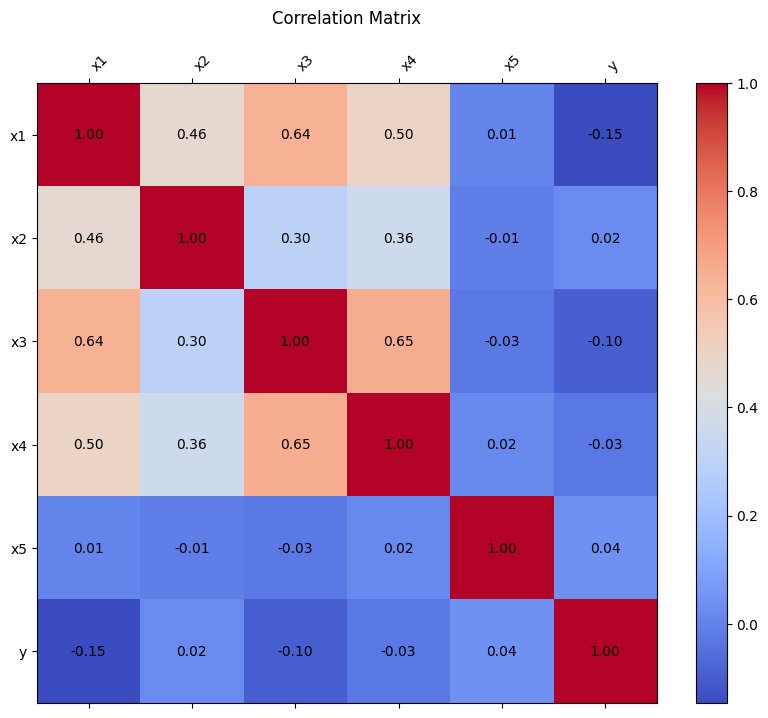

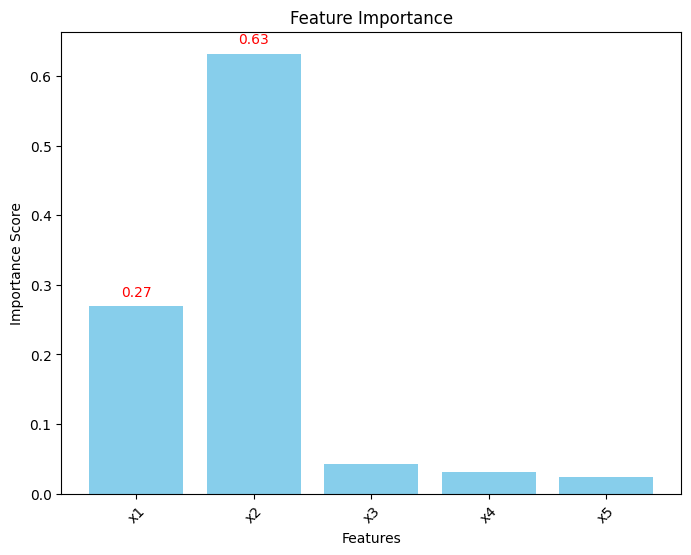

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

df = pd.read_csv('projet_1_data.csv')
df.describe()

#_=scatter_matrix(df, diagonal='kde', figsize=(10,10),marker='.')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
correlation_matrix = np.corrcoef(X_scaled.T)

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Plot the correlation matrix
plt.figure(figsize=(10, 8))
plt.matshow(correlation_matrix, fignum=1, cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45, ha='left')
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)

# Add correlation values in each square
for (i, j), value in np.ndenumerate(correlation_matrix.values):
    plt.text(j, i, f'{value:.2f}', ha='center', va='center', color='black')

plt.title("Correlation Matrix", pad=20)
plt.show()

# Feature importance using Random Forest
X = df.drop(columns=['y'])
y = df['y']

# Train the model
model = RandomForestRegressor(random_state=42)
model.fit(X, y)

# Get feature importance scores
feature_importances = model.feature_importances_

# Create a bar plot for feature importance
plt.figure(figsize=(8, 6))
plt.bar(X.columns, feature_importances, color='skyblue')
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)

# Highlight important features
for i, (feature, importance) in enumerate(zip(X.columns, feature_importances)):
    if feature in ['x1', 'x2']:
        plt.text(i, importance + 0.01, f'{importance:.2f}', ha='center', va='bottom', color='red')

plt.show()



Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Random Forest Model:
 RandomForestClassifier(n_estimators=200, random_state=42)
Accuracy: 0.9431137724550899
Classification Report:
               precision    recall  f1-score   support

         0.0       0.93      1.00      0.96       258
         1.0       0.98      0.76      0.86        76

    accuracy                           0.94       334
   macro avg       0.96      0.88      0.91       334
weighted avg       0.95      0.94      0.94       334



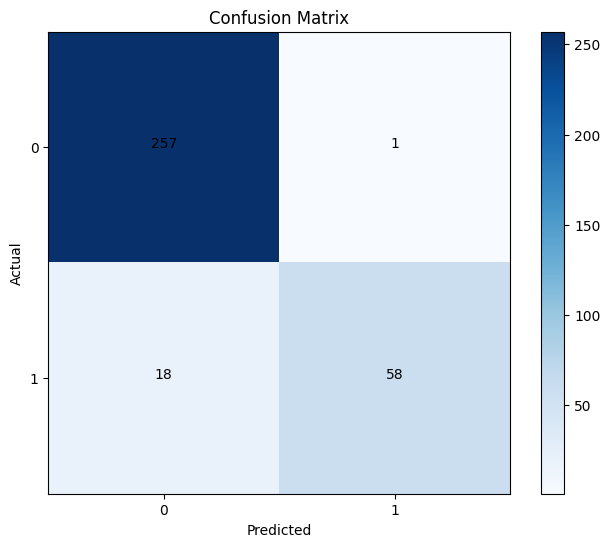

In [4]:
#model 1

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt


X = df[['x1', 'x2']]  # Select the features
y = df['y']  # Target variable

# Splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Defining the parameter grid for Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1, 
    verbose=1
)

# Fitting
grid_search_rf.fit(X_train, y_train)

# Getting the best model
model1 = grid_search_rf.best_estimator_

# Making prediction
y_pred_best_rf = model1.predict(X_test)

# Evaluating the best model
accuracy = accuracy_score(y_test, y_pred_best_rf)
report = classification_report(y_test, y_pred_best_rf)
conf_matrix = confusion_matrix(y_test, y_pred_best_rf)

print("Best Random Forest Model:\n", model1)
print("Accuracy:", accuracy)
print("Classification Report:\n", report)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = [0, 1]
plt.xticks(tick_marks, [0, 1])
plt.yticks(tick_marks, [0, 1])

# Add labels
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, conf_matrix[i, j], horizontalalignment='center', color='black')

plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()



Classification Report for Decision Tree:
              precision    recall  f1-score   support

         0.0       0.90      0.99      0.94       434
         1.0       0.93      0.62      0.75       122

    accuracy                           0.91       556
   macro avg       0.91      0.80      0.84       556
weighted avg       0.91      0.91      0.90       556

Model Accuracy: 0.91


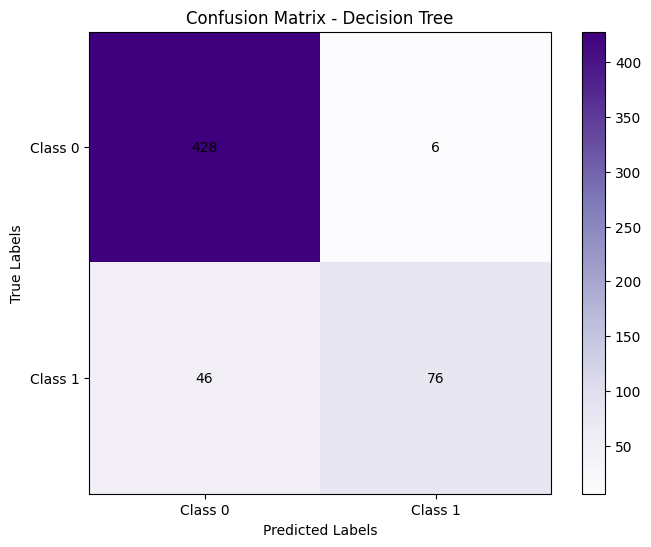

In [5]:
#model 2

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Use only x1 and x2 for the model
X_important = df[['x1', 'x2']]
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(X_important, y, test_size=0.5, random_state=42)


model2 = DecisionTreeClassifier(random_state=42, max_depth=3)
model2.fit(X_train, y_train)

y_pred = model2.predict(X_test)

print("Classification Report for Decision Tree:")
print(classification_report(y_test, y_pred))
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix, cmap='Purples')
plt.colorbar()

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.xticks(np.arange(2), labels=["Class 0", "Class 1"])
plt.yticks(np.arange(2), labels=["Class 0", "Class 1"])

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, conf_matrix[i, j], ha='center', va='center', color='black')

plt.show()


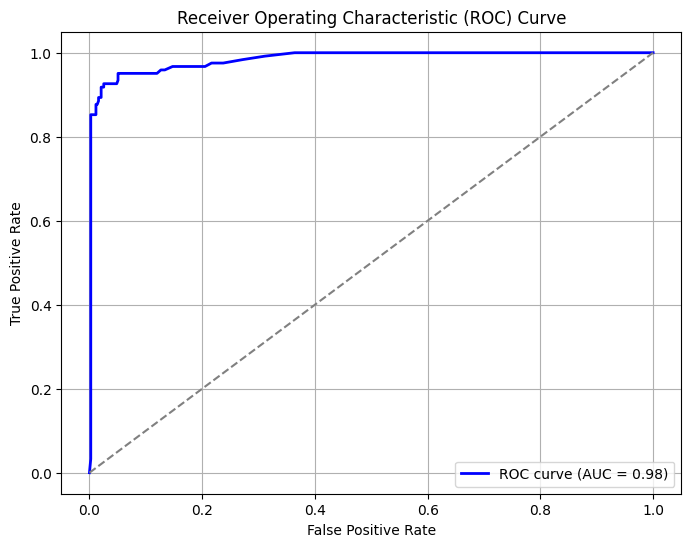

In [9]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

y_pred_prob = model1.predict_proba(X_test)[:, 1]

# Calculating the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Calculating the AUC
roc_auc = auc(fpr, tpr)

# Plotting the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

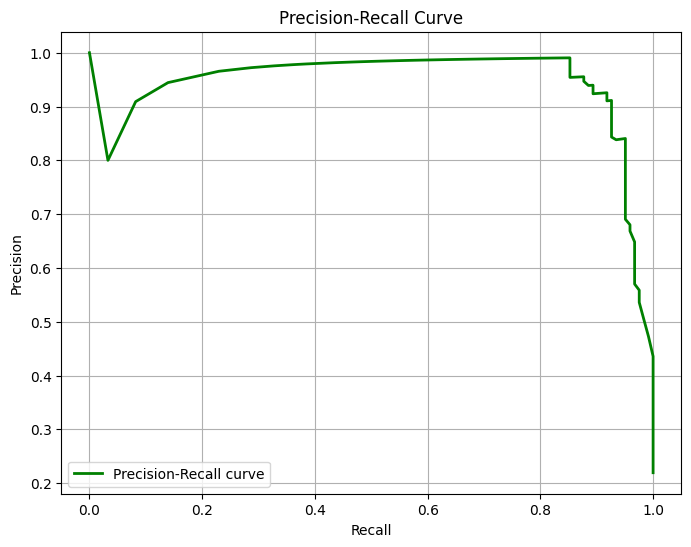

In [10]:

precision, recall, pr_thresholds = precision_recall_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='green', lw=2, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid()
plt.show()

---
#### Verification

Veuillez valider vos modèles à l'aide de la fonction ci-dessous. Le premier modèle doit être celui que vous considérez comme le plus performant.

⚠️ - Cette fonction vérifie uniquement que votre soumission est vérifiable. Elle ne donne aucune indication sur la validité de la soumission (e.g. type de ML) ou sa qualité.

Vous pouvez spécifier les caractéristiques principales sous deux formats :

- Une liste de caractéristiques commune à tous les modèles.
- Une liste de listes de caractéristiques, correspondant à chaque modèle (voir exemple), dans le même ordre.

Chaque list de caractéristiques peut être spécifiée de deux manières :

- Une liste de noms de colonnes pertinentes, dans l'ordre désiré, par exemple ['x3', 'x1', 'x4'].
- Une liste de valeurs booléennes correspondant aux colonnes, où True indique une colonne pertinente, par exemple [True, False, True, False, True] pour sélectionner les colonnes ['x1', 'x3', 'x5'].

Notez que si le nombre de caractéristiques attendues par votre modèle ne correspond pas au nombre de caractéristiques spécifiées dans la fonction, celle-ci ignorera cette liste de caractéristiques et supposera que le modèle inclut une étape de filtrage automatique des caractéristiques et validera le modèle avec toutes les variables du fichier de hold-out (dans ce cas la liste de caractéristiques sert uniquement à vérifier votre sélection).

Vous pouvez également définir un seuil de détection (e.g. pour contrôler le taux de fausses négatives): soit un seuil commun pour les deux modèles, soit une liste de seuils distincts par modèle (ou seuil=None pour utiliser les valeurs par défaut).

In [7]:
# executer la commande ci-dessous si nécessaire (enlever le #).
# !pip install -e ./eng209

In [8]:
from importlib import reload
import eng209.verify
reload(eng209.verify)
from eng209.verify import verify_q1

In [18]:
# Remplacez best_model et second_best_model par vos modèles, et modifiez les caractéristiques et le seuil en conséquence.
best_model= model1
second_best_model= model2
caracteristiques=['x1','x2']
seuil=[0.5,0.5]

verify_q1(best_model, second_best_model, caracteristiques=caracteristiques, seuil=seuil)

Vérification ...
Info :  Même liste de caractéristiques ['x1', 'x2'] appliquées sur les 2 modèles.
Vérifiable
Vérifiable
